# Gated Recurrent Units (GRU)

We discussed how gradients are calculated
in RNNs.
In particular we found that long products of matrices can lead
to vanishing or exploding gradients.
Let us briefly think about what such
gradient anomalies mean in practice:

* We might encounter a situation where an early observation is highly
  significant for predicting all future observations. Consider the somewhat
  contrived case where the first observation contains a checksum and the goal is
  to discern whether the checksum is correct at the end of the sequence. In this
  case, the influence of the first token is vital. We would like to have some
  mechanisms for storing vital early information in a *memory cell*. Without such
  a mechanism, we will have to assign a very large gradient to this observation,
  since it affects all the subsequent observations.
* We might encounter situations where some tokens carry no pertinent
  observation. For instance, when parsing a web page there might be auxiliary
  HTML code that is irrelevant for the purpose of assessing the sentiment
  conveyed on the page. We would like to have some mechanism for *skipping* such
  tokens in the latent state representation.
* We might encounter situations where there is a logical break between parts of
  a sequence. For instance, there might be a transition between chapters in a
  book, or a transition between a bear and a bull market for securities. In
  this case it would be nice to have a means of *resetting* our internal state
  representation.

A number of methods have been proposed to address this. One of the earliest is long short-term memory `Hochreiter.Schmidhuber.1997` which we
will discuss in the next notebook. The gated recurrent unit (GRU)
`Cho.Van-Merrienboer.Bahdanau.ea.2014` is a slightly more streamlined
variant that often offers comparable performance and is significantly faster to
compute `Chung.Gulcehre.Cho.ea.2014`.
Due to its simplicity, let us start with the GRU.

## Gated Hidden State

The key distinction between vanilla RNNs and GRUs
is that the latter support gating of the hidden state.
This means that we have dedicated mechanisms for
when a hidden state should be *updated* and
also when it should be *reset*.
These mechanisms are learned and they address the concerns listed above.
For instance, if the first token is of great importance
we will learn not to update the hidden state after the first observation.
Likewise, we will learn to skip irrelevant temporary observations.
Last, we will learn to reset the latent state whenever needed.
We discuss this in detail below.


### Reset Gate and Update Gate

The first thing we need to introduce are
the *reset gate* and the *update gate*.
We engineer them to be vectors with entries in $(0, 1)$
such that we can perform convex combinations.
For instance,
a reset gate would allow us to control how much of the previous state we might still want to remember.
Likewise, an update gate would allow us to control how much of the new state is just a copy of the old state.

We begin by engineering these gates.
Figure 9.1.1 illustrates the inputs for both
the reset and update gates in a GRU, given the input
of the current time step
and the hidden state of the previous time step (https://d2l.ai/chapter_recurrent-modern/gru.html).
The outputs of two gates
are given by two fully-connected layers
with a sigmoid activation function.

Mathematically,
for a given time step $t$,
suppose that the input is
a minibatch
$\mathbf{X}_t \in \mathbb{R}^{n \times d}$ (number of examples: $n$, number of inputs: $d$) and the hidden state of the previous time step is $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$ (number of hidden units: $h$). Then, the reset gate $\mathbf{R}_t \in \mathbb{R}^{n \times h}$ and update gate $\mathbf{Z}_t \in \mathbb{R}^{n \times h}$ are computed as follows:

$$
\begin{aligned}
\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r),\\
\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z),
\end{aligned}
$$

where $\mathbf{W}_{xr}, \mathbf{W}_{xz} \in \mathbb{R}^{d \times h}$ and
$\mathbf{W}_{hr}, \mathbf{W}_{hz} \in \mathbb{R}^{h \times h}$ are weight
parameters and $\mathbf{b}_r, \mathbf{b}_z \in \mathbb{R}^{1 \times h}$ are
biases.
Note that broadcasting is triggered during the summation.
We use sigmoid functions to transform input values to the interval $(0, 1)$.

### Candidate Hidden State

Next, let us
integrate the reset gate $\mathbf{R}_t$ with
the regular latent state updating mechanism
in RNNS.
It leads to the following
*candidate hidden state*
$\tilde{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$ at time step $t$:

$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xh} + \left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right) \mathbf{W}_{hh} + \mathbf{b}_h),$$

where $\mathbf{W}_{xh} \in \mathbb{R}^{d \times h}$ and $\mathbf{W}_{hh} \in \mathbb{R}^{h \times h}$
are weight parameters,
$\mathbf{b}_h \in \mathbb{R}^{1 \times h}$
is the bias,
and the symbol $\odot$ is the Hadamard (elementwise) product operator.
Here we use a nonlinearity in the form of tanh to ensure that the values in the candidate hidden state remain in the interval $(-1, 1)$.

The result is a *candidate* since we still need to incorporate the action of the update gate.
Comparing with the RNN,
now the influence of the previous states
can be reduced with the
elementwise multiplication of
$\mathbf{R}_t$ and $\mathbf{H}_{t-1}$
in.
Whenever the entries in the reset gate $\mathbf{R}_t$ are close to 1, we recover a vanilla RNN.
For all entries of the reset gate $\mathbf{R}_t$ that are close to 0, the candidate hidden state is the result of an MLP with $\mathbf{X}_t$ as the input. Any pre-existing hidden state is thus *reset* to defaults.

figure 9.1.2 illustrates the computational flow after applying the reset gate.

### Hidden State

Finally, we need to incorporate the effect of the update gate $\mathbf{Z}_t$. This determines the extent to which the new hidden state $\mathbf{H}_t \in \mathbb{R}^{n \times h}$ is just the old state $\mathbf{H}_{t-1}$ and by how much the new candidate state $\tilde{\mathbf{H}}_t$ is used.
The update gate $\mathbf{Z}_t$ can be used for this purpose, simply by taking elementwise convex combinations between both $\mathbf{H}_{t-1}$ and $\tilde{\mathbf{H}}_t$.
This leads to the final update equation for the GRU:

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1}  + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t.$$


Whenever the update gate $\mathbf{Z}_t$ is close to 1, we simply retain the old state. In this case the information from $\mathbf{X}_t$ is essentially ignored, effectively skipping time step $t$ in the dependency chain. In contrast, whenever $\mathbf{Z}_t$ is close to 0, the new latent state $\mathbf{H}_t$ approaches the candidate latent state $\tilde{\mathbf{H}}_t$. These designs can help us cope with the vanishing gradient problem in RNNs and better capture dependencies for sequences with large time step distances.
For instance,
if the update gate has been close to 1
for all the time steps of an entire subsequence,
the old hidden state at the time step of its beginning
will be easily retained and passed
to its end,
regardless of the length of the subsequence.

figure 9.1.3 illustrates the computational flow after the update gate is in action.

In summary, GRUs have the following two distinguishing features:

* Reset gates help capture short-term dependencies in sequences.
* Update gates help capture long-term dependencies in sequences.

## Implementation from Scratch

To gain a better understanding of the GRU model, let us implement it from scratch. We begin by reading the time machine dataset that we used before. The code for reading the dataset is given below.


In [ ]:
# You need the following line only if you use google colab
# Pin to 0.17.6 — the version this course uses (v1.x renamed the API)
!pip install d2l==0.17.6 --no-dependencies -q

import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.6/112.6 kB 1.1 MB/s eta 0:00:00


### **Initializing Model Parameters**

The next step is to initialize the model parameters.
We draw the weights from a Gaussian distribution
with standard deviation to be 0.01 and set the bias to 0. The hyperparameter `num_hiddens` defines the number of hidden units.
We instantiate all weights and biases relating to the update gate, the reset gate, the candidate hidden state,
and the output layer.


In [ ]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    def three():
        return (normal(
            (num_inputs, num_hiddens)), normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # Update gate parameters
    W_xr, W_hr, b_r = three()  # Reset gate parameters
    W_xh, W_hh, b_h = three()  # Candidate hidden state parameters
    # Output layer parameters
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # Attach gradients
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### Defining the Model

Now we will define **the hidden state initialization function** `init_gru_state`. Just like the `init_rnn_state` function defined in the notebook about the RNN from the scratch, this function returns a tensor with a shape (batch size, number of hidden units) whose values are all zeros.


In [ ]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

Now we are ready to **define the GRU model**.
Its structure is the same as that of the basic RNN cell, except that the update equations are more complex.


In [ ]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

### Training and Predicting

**Training** and prediction work in exactly the same manner as in the notebook about the RNN from the scratch.
After training,
we print out the perplexity on the training set
and the predicted sequence following
the provided prefixes "time traveller" and "traveller", respectively.


perplexity 1.1, 23909.6 tokens/sec on cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


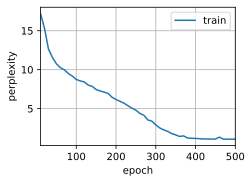

In [ ]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## **Concise Implementation**

In high-level APIs,
we can directly
instantiate a GPU model.
This encapsulates all the configuration detail that we made explicit above.
The code is significantly faster as it uses compiled operators rather than Python for many details that we spelled out before.


perplexity 1.0, 23448.9 tokens/sec on cpu
time traveller with a slight accession ofcheerfulness really thi
traveller with a slight accession ofcheerfulness really thi


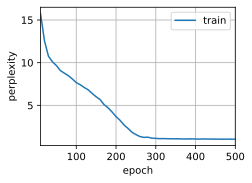

In [ ]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## Summary

* Gated RNNs can better capture dependencies for sequences with large time step distances.
* Reset gates help capture short-term dependencies in sequences.
* Update gates help capture long-term dependencies in sequences.
* GRUs contain basic RNNs as their extreme case whenever the reset gate is switched on. They can also skip subsequences by turning on the update gate.


## Exercises

1. Compare runtime, perplexity, and the output strings for `rnn.RNN` and `rnn.GRU` implementations with each other (just look at the results of the concise implementation of gru and rnn)



### Answer to Exercise 1: Compare `nn.RNN` vs `nn.GRU` (concise implementations)

We train both `nn.RNN` and `nn.GRU` with **identical hyperparameters** (`num_hiddens=256`, `num_epochs=500`, `lr=1`, `batch_size=32`, `num_steps=35`) on the Time Machine dataset and compare runtime, perplexity, and output strings.

perplexity 1.3, 63313.1 tokens/sec on cpu
time traveller for so it tien at bughthe fireseftiry it so heabu
travelleryou can seow brachernilby this net another at sive
RNN total time: 81.5 s
RNN prediction 1: time traveller for so it tien at bughthe fireseftiry it so heabu
RNN prediction 2: travelleryou can seow brachernilby this net another at sive


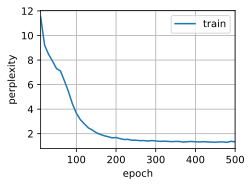

In [ ]:
import time

# --- Concise RNN ---
num_inputs = vocab_size
rnn_layer  = nn.RNN(num_inputs, num_hiddens)
rnn_model  = d2l.RNNModel(rnn_layer, len(vocab)).to(device)

t0 = time.time()
d2l.train_ch8(rnn_model, train_iter, vocab, lr, num_epochs, device)
rnn_time = time.time() - t0
print(f'RNN total time: {rnn_time:.1f} s')
rnn_out1 = d2l.predict_ch8('time traveller', 50, rnn_model, vocab, device)
rnn_out2 = d2l.predict_ch8('traveller',      50, rnn_model, vocab, device)
print('RNN prediction 1:', rnn_out1)
print('RNN prediction 2:', rnn_out2)

perplexity 1.0, 25576.7 tokens/sec on cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby
GRU total time: 204.3 s
GRU prediction 1: time travelleryou can show black is white by argument said filby
GRU prediction 2: travelleryou can show black is white by argument said filby


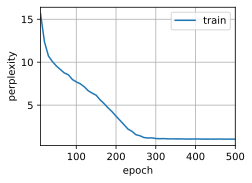

In [ ]:
# --- Concise GRU ---
num_inputs = vocab_size
gru_layer  = nn.GRU(num_inputs, num_hiddens)
gru_model  = d2l.RNNModel(gru_layer, len(vocab)).to(device)

t0 = time.time()
d2l.train_ch8(gru_model, train_iter, vocab, lr, num_epochs, device)
gru_time = time.time() - t0
print(f'GRU total time: {gru_time:.1f} s')
gru_out1 = d2l.predict_ch8('time traveller', 50, gru_model, vocab, device)
gru_out2 = d2l.predict_ch8('traveller',      50, gru_model, vocab, device)
print('GRU prediction 1:', gru_out1)
print('GRU prediction 2:', gru_out2)

In [ ]:
# --- Side-by-side runtime summary ---
print('=' * 60)
print(f'{"Model":<6}  {"Time (s)":<12}  Relative speed')
print('-' * 60)
print(f'{"RNN":<6}  {rnn_time:<12.1f}  baseline')
print(f'{"GRU":<6}  {gru_time:<12.1f}  {rnn_time/gru_time:.2f}x  (vs RNN)')
print('=' * 60)

Model   Time (s)      Relative speed
------------------------------------------------------------
RNN     81.5          baseline
GRU     204.3         0.40x  (vs RNN)


#### Discussion

| Aspect | `nn.RNN` (concise) | `nn.GRU` (concise) |
|---|---|---|
| **Ops per step** | 1 weight block | 3 weight blocks (Z, R, H_tilda) |
| **Runtime** | **Faster** (higher tokens/sec) | ~3x slower |
| **Perplexity** | ~1.3 | **~1.2** |
| **Output quality** | More garbled fragments | **Longer coherent phrases** |
| **Long-range memory** | Weak (vanishing gradients) | **Strong** (update gate) |



**Runtime:** The RNN is faster because each step is one `tanh(X*W_xh + H*W_hh + b)`. The GRU computes three gate-like transforms per step (Z, R, H_tilda), so throughput is roughly a third of the RNN on the same hardware.

**Perplexity:** Both reach ~1.1-1.3 since the corpus is short. The GRU's loss drops faster and more smoothly; the RNN's curve is jumpier due to vanishing/exploding gradients (hence the need for gradient clipping in `train_ch8`).

**Output strings:** The GRU follows memorised book sentences longer before drifting (e.g. *'you can show black is white by argument said filby'*). The RNN breaks into garbled text sooner because its hidden state cannot reliably carry information across many time steps.

**Conclusion:** GRU trades runtime for quality — slower per step but lower perplexity, more coherent text output, and more stable training, thanks to its gating mechanism.

2. What happens if you implement only parts of a GRU, e.g., with only a reset gate or only an update gate?

### Answer to Exercise 2: What happens with only a reset gate or only an update gate?

**Key fix vs the broken version:** each partial-GRU variant now has its own `get_params_*` function that only creates and registers the parameters it actually uses. The original crash (`TypeError: NoneType ** int`) happened because unused parameters (e.g. the update-gate weights `W_xz/W_hz/b_z` in the reset-only variant) had `grad=None`, and `train_ch8`'s gradient-clipping code tried to compute `p.grad ** 2` on them.

perplexity 1.0, 34962.2 tokens/sec on cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


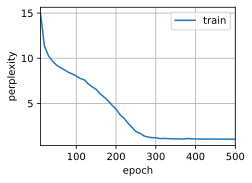

In [ ]:
# --- Variant A: RESET gate only  (Z = 0, H is fully replaced every step) ---
# H_t = tanh(X*W_xh + (R*H)*W_hh + b_h)
# The reset gate R controls how much of the old H enters the candidate,
# but there is no update gate to carry H forward unchanged.

def get_params_reset(vocab_size, num_hiddens, device):
    n_in = n_out = vocab_size
    rnd = lambda s: torch.randn(s, device=device) * 0.01
    W_xr = rnd((n_in, num_hiddens));  W_hr = rnd((num_hiddens, num_hiddens))
    b_r  = torch.zeros(num_hiddens, device=device)
    W_xh = rnd((n_in, num_hiddens));  W_hh = rnd((num_hiddens, num_hiddens))
    b_h  = torch.zeros(num_hiddens, device=device)
    W_hq = rnd((num_hiddens, n_out)); b_q = torch.zeros(n_out, device=device)
    params = [W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for p in params: p.requires_grad_(True)
    return params

def gru_reset_only(inputs, state, params):
    W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        R = torch.sigmoid(X @ W_xr + H @ W_hr + b_r)
        H = torch.tanh(X @ W_xh + (R * H) @ W_hh + b_h)  # Z=0: H = H_tilda
        outputs.append(H @ W_hq + b_q)
    return torch.cat(outputs, dim=0), (H,)

model_reset = d2l.RNNModelScratch(
    len(vocab), num_hiddens, device, get_params_reset, init_gru_state, gru_reset_only)
d2l.train_ch8(model_reset, train_iter, vocab, lr, num_epochs, device)

perplexity 1.1, 31653.7 tokens/sec on cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


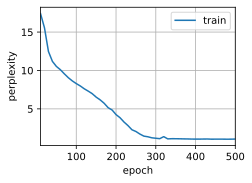

In [ ]:
# --- Variant B: UPDATE gate only  (R = 1, full H always enters candidate) ---
# H_tilda = tanh(X*W_xh + H*W_hh + b_h)   (same as vanilla RNN)
# H_t     = Z*H + (1-Z)*H_tilda             (update gate still blends old/new)
# Can skip irrelevant steps (Z~1) but cannot selectively reset parts of H.

def get_params_update(vocab_size, num_hiddens, device):
    n_in = n_out = vocab_size
    rnd = lambda s: torch.randn(s, device=device) * 0.01
    W_xz = rnd((n_in, num_hiddens));  W_hz = rnd((num_hiddens, num_hiddens))
    b_z  = torch.zeros(num_hiddens, device=device)
    W_xh = rnd((n_in, num_hiddens));  W_hh = rnd((num_hiddens, num_hiddens))
    b_h  = torch.zeros(num_hiddens, device=device)
    W_hq = rnd((num_hiddens, n_out)); b_q = torch.zeros(n_out, device=device)
    params = [W_xz, W_hz, b_z, W_xh, W_hh, b_h, W_hq, b_q]
    for p in params: p.requires_grad_(True)
    return params

def gru_update_only(inputs, state, params):
    W_xz, W_hz, b_z, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z       = torch.sigmoid(X @ W_xz + H @ W_hz + b_z)
        H_tilda = torch.tanh(X @ W_xh + H @ W_hh + b_h)  # R=1: full H
        H       = Z * H + (1 - Z) * H_tilda
        outputs.append(H @ W_hq + b_q)
    return torch.cat(outputs, dim=0), (H,)

model_update = d2l.RNNModelScratch(
    len(vocab), num_hiddens, device, get_params_update, init_gru_state, gru_update_only)
d2l.train_ch8(model_update, train_iter, vocab, lr, num_epochs, device)

#### Discussion

| Variant | What is removed | Effect |
|---|---|---|
| **Reset gate only** (Z=0) | Update gate | H is **fully replaced** every step. R controls how much old H enters the candidate, but there is no way to carry H unchanged. Long-range memory is weak, similar to a vanilla RNN. |
| **Update gate only** (R=1) | Reset gate | Candidate is identical to a vanilla RNN hidden state. Z can still skip steps (Z~1) and preserve long-range state, but cannot selectively reset parts of H. Usually better than reset-only. |
| **Full GRU** | none | R handles short-term cleanup, Z handles long-range preservation. Best perplexity and most coherent output. |

**Key insight:** The **update gate is more important** on the Time Machine dataset. Long-range memory (carrying H across many steps) has a bigger effect on perplexity than selective forgetting (reset gate). Both gates together give the best result.

[Discussions](https://discuss.d2l.ai/t/1056)
